# Лабораторная работа 12

Тема: **Vanilla GAN для генерации цифр MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными экспериментами и комментариями.

> Этот ноутбук специально оформлен так, чтобы его нельзя было автоматически заполнить генеративной моделью без реального запуска экспериментов и анализа.  
> Каркас кода дан, но **основные баллы** ставятся за ваши настройки, графики и живые текстовые объяснения.


## 1. Ваше понимание задачи GAN (если не знаетет, что такое GAN - можно гуглить и спрашивать LLM)

Перед запуском кода опишите текущее понимание (8–12 предложений):

1. Для чего нужны генеративно‑состязательные сети (GAN) и чем их цель отличается от классической задачи классификации.  
2. Как вы интуитивно представляете «игру» генератора и дискриминатора: кто что пытается сделать и почему это неустойчивая задача.  
3. Каких визуальных артефактов вы ожидаете от **простого** Vanilla GAN на MNIST (размытость, странные гибриды цифр и т.п.).

Пишите своими словами, как если бы объясняли задачу одногруппнику.


In [15]:
intro_text = """ЗДЕСЬ ОПИШИТЕ СВОЁ ПОНИМАНИЕ GAN: КТО ТАКОЙ ГЕНЕРАТОР,
КТО ТАКОЙ ДИСКРИМИНАТОР, КАК ОНИ ВЗАИМОДЕЙСТВУЮТ И ЧТО ВЫ
ОЖИДАЕТЕ УВИДЕТЬ НА MNIST. НЕ МЕНЕЕ 8 ПРЕДЛОЖЕНИЙ.

1. Генеративно-состязательные модели обучаются без учителя. Модель состоит из генератора, создающего новые данные, похожие на исходные,
и дискриминатора, учащегося отличать настоящие данные от сгенерированных. То есть данные не просто классифицируются, а еще создаются новые.

2. Генератор пытается обмануть дискриминатор, а дискриминатор - разоблачить генератор.
Такая задача может быть неустойчивой, потому что, в итоге, адекватных данных пользователь не получит ввиду этой борьбы.

3. От простого Vanilla GAN, думаю, будут артефакты в виде размытости точно, а насчет остального не знаю.
Возможно, еще будут не прямо гибриды цифр, а рандомные линии вне цифры."""
print(intro_text)

ЗДЕСЬ ОПИШИТЕ СВОЁ ПОНИМАНИЕ GAN: КТО ТАКОЙ ГЕНЕРАТОР,
КТО ТАКОЙ ДИСКРИМИНАТОР, КАК ОНИ ВЗАИМОДЕЙСТВУЮТ И ЧТО ВЫ
ОЖИДАЕТЕ УВИДЕТЬ НА MNIST. НЕ МЕНЕЕ 8 ПРЕДЛОЖЕНИЙ.

1. Генеративно-состязательные модели обучаются без учителя. Модель состоит из генератора, создающего новые данные, похожие на исходные,
и дискриминатора, учащегося отличать настоящие данные от сгенерированных. То есть данные не просто классифицируются, а еще создаются новые.

2. Генератор пытается обмануть дискриминатор, а дискриминатор - разоблачить генератор.
Такая задача может быть неустойчивой, потому что, в итоге, адекватных данных пользователь не получит ввиду этой борьбы.

3. От простого Vanilla GAN, думаю, будут артефакты в виде размытости точно, а насчет остального не знаю.
Возможно, еще будут не прямо гибриды цифр, а рандомные линии вне цифры.


## 2. Импорт, настройки и данные (MNIST)


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 0  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 256

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cuda
MY_SEED = 0
Размер train: 60000


Посмотрим на несколько реальных изображений, которые GAN должен научиться имитировать.


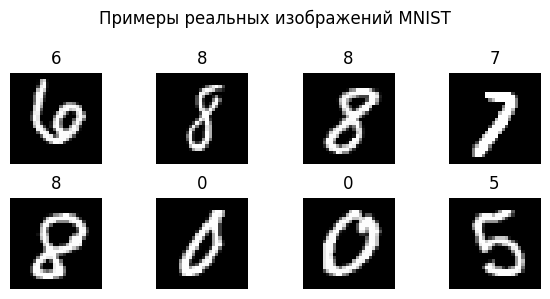

In [17]:
real_images, real_labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(real_images[i].squeeze(0), cmap="gray")
    plt.title(str(real_labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры реальных изображений MNIST")
plt.tight_layout()
plt.show()

### Мини‑комментарий по данным

Кратко (3–5 предложений) опишите:
- насколько, на ваш взгляд, легко/сложно генератору научиться имитировать такие цифры;  
- какие особенности рукописных цифр могут затруднить генерацию (разные стили, толщина линий и т.п.).


In [18]:
data_comment = """ЗДЕСЬ ОПИШИТЕ, НАСКОЛЬКО "ПРОСТЫМИ" ИЛИ "СЛОЖНЫМИ" ВАМ
КАЖУТСЯ ИЗОБРАЖЕНИЯ MNIST ДЛЯ ГЕНЕРАЦИИ, И КАКИЕ ХАРАКТЕРИСТИКИ
РУКОПИСНЫХ ЦИФР МОГУТ МЕШАТЬ ГЕНЕРАТОРУ.

Я думаю, что такие цифры генератору имитировать легко, потому что у них простая структура.
Затруднить генерацию может схожесть некоторых цифр между собой (2, 3, 8, например)."""
print(data_comment)

ЗДЕСЬ ОПИШИТЕ, НАСКОЛЬКО "ПРОСТЫМИ" ИЛИ "СЛОЖНЫМИ" ВАМ
КАЖУТСЯ ИЗОБРАЖЕНИЯ MNIST ДЛЯ ГЕНЕРАЦИИ, И КАКИЕ ХАРАКТЕРИСТИКИ
РУКОПИСНЫХ ЦИФР МОГУТ МЕШАТЬ ГЕНЕРАТОРУ.

Я думаю, что такие цифры генератору имитировать легко, потому что у них простая структура.
Затруднить генерацию может схожесть некоторых цифр между собой (2, 3, 8, например).


## 3. Архитектура генератора и дискриминатора

Используем классический Vanilla GAN с полносвязными сетями:
- Генератор: принимает случайный шум `z` размерности 100 и выдаёт изображение 28×28 (через `tanh`, в диапазоне [-1, 1]);  
- Дискриминатор: принимает изображение 28×28 и выдаёт вероятность того, что оно "реальное".


In [19]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


### Краткий анализ архитектуры

Ответьте в 4–6 предложениях:
- почему в генераторе используется `tanh` на выходе и совместим ли он с нормализацией входных данных;  
- зачем в дискриминаторе используется `LeakyReLU`, а не обычный `ReLU`.


In [20]:
arch_comment = """ЗДЕСЬ ОБЪЯСНИТЕ ВЫБОР АКТИВАЦИЙ В ГЕНЕРАТОРЕ И ДИСКРИМИНАТОРЕ,
А ТАКЖЕ СВЯЗЬ МЕЖДУ НОРМАЛИЗАЦИЕЙ ДАННЫХ И ФУНКЦИЕЙ tanh НА ВЫХОДЕ G.

В генераторе используется функция активации tanh, потому что она выдает знаечения в диапазоне [-1, 1].
Это совместимо с нормализацией входных данных, ведь там черные (-1), серые (0) и белые (1) пиксели.

В дискриминаторе LeakyReLU, чтобы при отрицательных входах дать им небольшое значение, а не обнулять полностью.
Это нужно для более стабильной тренировки модели."""
print(arch_comment)

ЗДЕСЬ ОБЪЯСНИТЕ ВЫБОР АКТИВАЦИЙ В ГЕНЕРАТОРЕ И ДИСКРИМИНАТОРЕ,
А ТАКЖЕ СВЯЗЬ МЕЖДУ НОРМАЛИЗАЦИЕЙ ДАННЫХ И ФУНКЦИЕЙ tanh НА ВЫХОДЕ G.

В генераторе используется функция активации tanh, потому что она выдает знаечения в диапазоне [-1, 1].
Это совместимо с нормализацией входных данных, ведь там черные (-1), серые (0) и белые (1) пиксели.

В дискриминаторе LeakyReLU, чтобы при отрицательных входах дать им небольшое значение, а не обнулять полностью.
Это нужно для более стабильной тренировки модели.


## 4. Функция потерь, оптимизаторы и фиксированный шум

Используем бинарную кросс‑энтропию и два оптимизатора Adam (для G и D).


In [21]:
criterion = nn.BCELoss()

lr = 2e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 100])


## 5. Цикл обучения GAN с журналированием лоссов

На каждой итерации:

1. Обновляем дискриминатор: считаем лосс на реальных и сгенерированных изображениях.  
2. Обновляем генератор: генерируем фейки и стараемся заставить дискриминатор считать их реальными.


Эпоха 1/20 | loss_G=6.9168, loss_D=0.1380


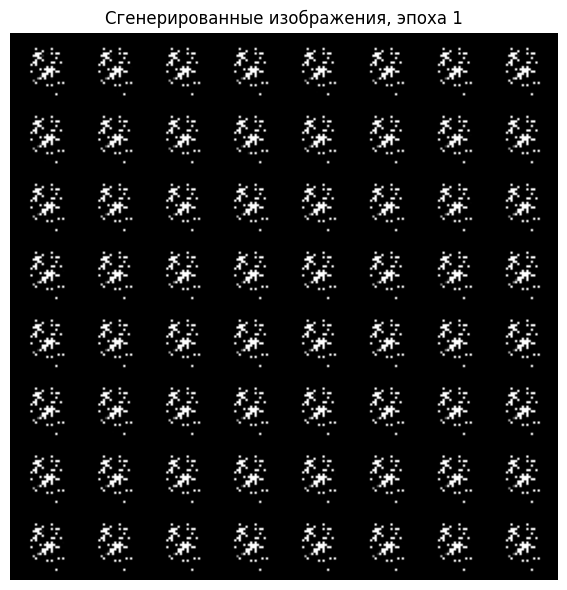

Эпоха 2/20 | loss_G=5.1428, loss_D=0.0573
Эпоха 3/20 | loss_G=6.3268, loss_D=0.0102
Эпоха 4/20 | loss_G=7.2734, loss_D=0.0017
Эпоха 5/20 | loss_G=7.3506, loss_D=0.0015


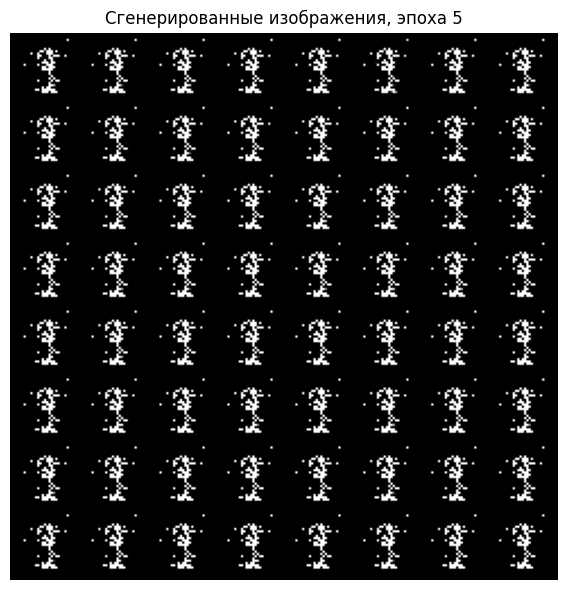

Эпоха 6/20 | loss_G=6.7275, loss_D=0.1018
Эпоха 7/20 | loss_G=7.0662, loss_D=0.0649
Эпоха 8/20 | loss_G=6.4358, loss_D=0.0067
Эпоха 9/20 | loss_G=14.5741, loss_D=0.0550
Эпоха 10/20 | loss_G=56.4531, loss_D=0.0004


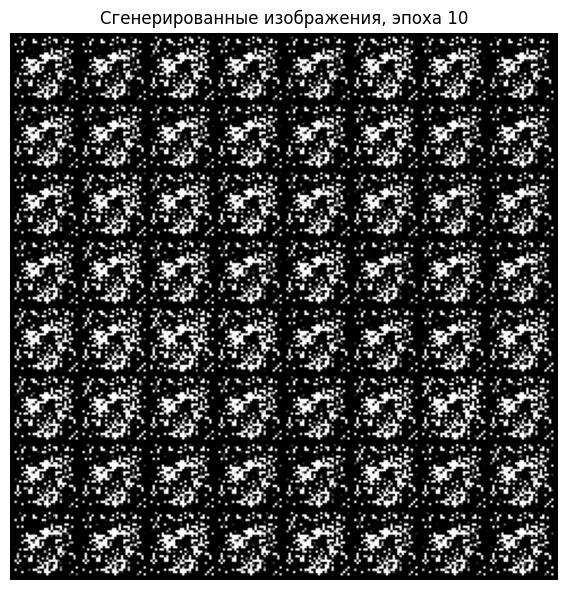

Эпоха 11/20 | loss_G=55.4626, loss_D=0.0000
Эпоха 12/20 | loss_G=55.1070, loss_D=0.0000
Эпоха 13/20 | loss_G=54.8642, loss_D=0.0000
Эпоха 14/20 | loss_G=54.5407, loss_D=0.0000
Эпоха 15/20 | loss_G=54.2669, loss_D=0.0000


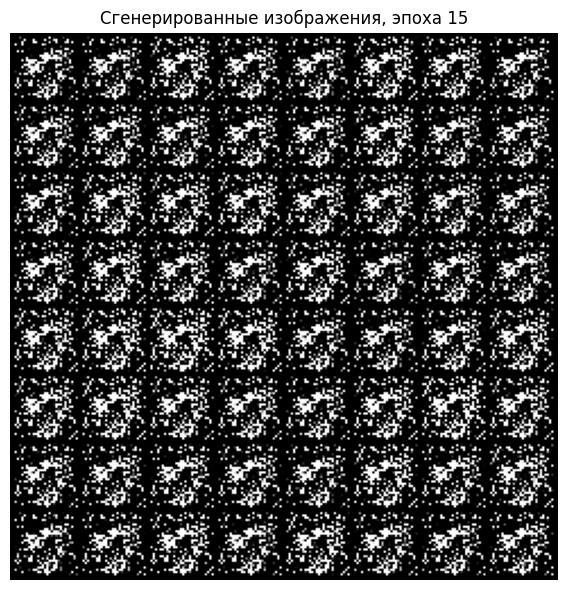

Эпоха 16/20 | loss_G=53.7949, loss_D=0.0000
Эпоха 17/20 | loss_G=19.4468, loss_D=0.1141
Эпоха 18/20 | loss_G=6.7003, loss_D=0.0037
Эпоха 19/20 | loss_G=7.3075, loss_D=0.0067
Эпоха 20/20 | loss_G=7.8877, loss_D=0.0345


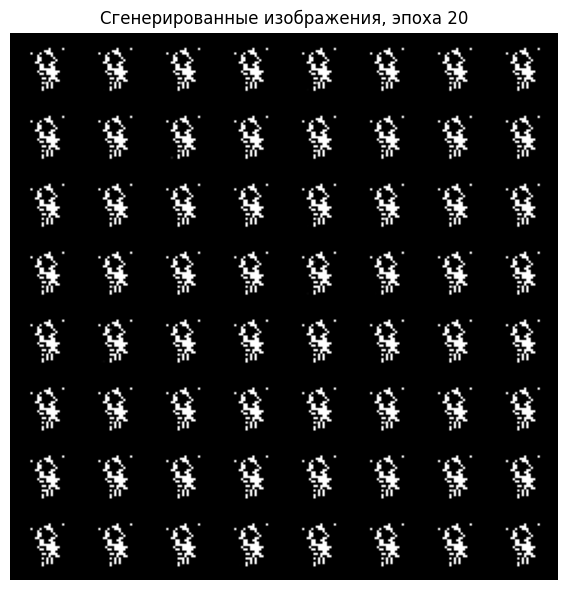

In [29]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 20  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

## 6. Графики лоссов генератора и дискриминатора

Посмотрим, как ведут себя лоссы G и D по эпохам.


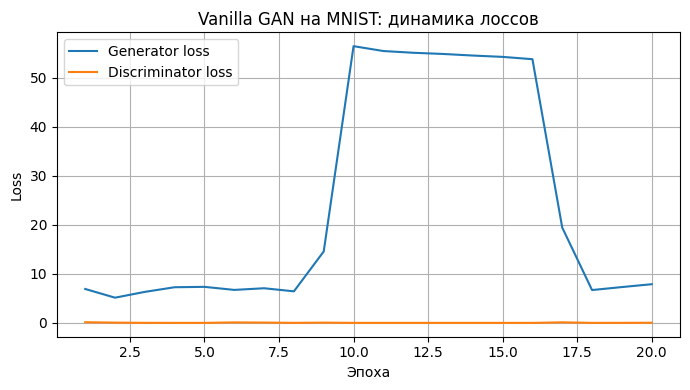

In [30]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ кривых лоссов

Опишите:
- есть ли тенденция к какому‑то «равновесию» между лоссами генератора и дискриминатора;  
- наблюдаются ли периодические колебания (кто «побеждает» на разных этапах обучения);  
- насколько реальное поведение лоссов совпало с вашими ожиданиями из раздела 1.


In [ ]:
loss_comment = """ЗДЕСЬ ПРОКОММЕНТИРУЙТЕ ГРАФИКИ loss_G И loss_D: КТО КОГО
ПЕРЕИГРЫВАЕТ НА РАЗНЫХ ЭТАПАХ, ВИДНО ЛИ ПРИБЛИЖЕНИЕ К ПРИМЕРНОМУ
РАВНОВЕСИЮ И КАК ЭТО СОЧЕТАЕТСЯ С ТЕМ, ЧТО ВЫ ЧИТАЛИ/СЛЫШАЛИ О GAN.

Есть примерно одинаковый промежуток между кривыми от 0-ой до 8-ой эпохи и от 18-ой до 20-ой (на 20-ти эпохах). А на 8-12 loss_G да большой скачок вверх до ~56.
Пока могу точно сказать, что размер батча должен быть большой (больше 32 хотя бы). На 32-ух loss_D стабильно 0, т.е. у генератора даже шанса не было.
Но в любом случае пока побеждает дискриминатор, у генератора очень большие лоссы, а сгенерированные картинки не похожи на цифры вообще."""
print(loss_comment)

ЗДЕСЬ ПРОКОММЕНТИРУЙТЕ ГРАФИКИ loss_G И loss_D: КТО КОГО
ПЕРЕИГРЫВАЕТ НА РАЗНЫХ ЭТАПАХ, ВИДНО ЛИ ПРИБЛИЖЕНИЕ К ПРИМЕРНОМУ
РАВНОВЕСИЮ И КАК ЭТО СОЧЕТАЕТСЯ С ТЕМ, ЧТО ВЫ ЧИТАЛИ/СЛЫШАЛИ О GAN.


## 7. Финальная генерация изображений и визуальная оценка

Сгенерируем новые изображения из случайного шума и посмотрим, насколько они похожи на реальный MNIST.


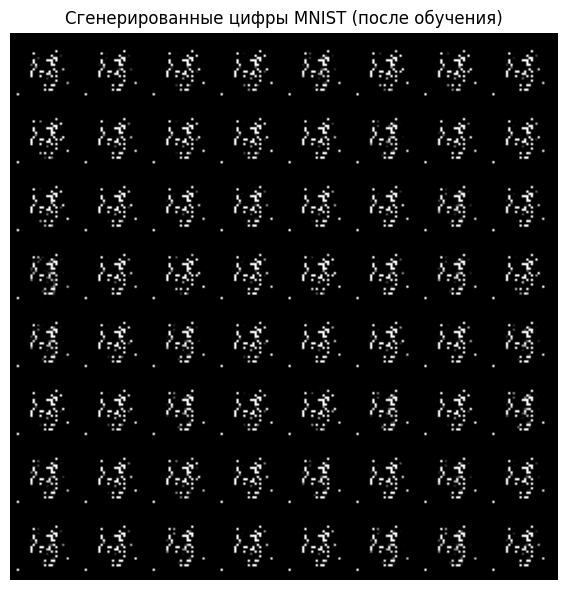

In [25]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

### Оценка качества сгенерированных цифр

Опишите:
- какие цифры получаются наиболее убедительными, а какие чаще всего выглядят как «шум» или гибриды;  
- встречаются ли явно «несуществующие» объекты, не похожие ни на одну цифру, и как часто;  
- как вы думаете, на что сильнее всего влияет качество: глубина сетей, размер `z_dim`, число эпох, баланс обучения G/D.


In [ ]:
gen_quality_comment = """ЗДЕСЬ ОПИШИТЕ, КАКОВО КАЧЕСТВО СГЕНЕРИРОВАННЫХ ЦИФР ПО ВАШЕМУ
ВИЗУАЛЬНОМУ ОЩУЩЕНИЮ. ПРИВЕДИТЕ ПРИМЕРЫ СЛУЧАЕВ, ГДЕ ЦИФРЫ ВЫГЛЯДЯТ
ОЧЕНЬ ПРАВДОПОДОБНО, И СЛУЧАЕВ, ГДЕ ОНИ ВЫЗЫВАЮТ СОМНЕНИЯ.

Может мне так "повезло", но все сгенерированные картинки не похожи ни на одну цифру (при базовых настройках).
Думаю, что на качество больше все влияет глубина сетей и баланс обучения G/D."""
print(gen_quality_comment)

ЗДЕСЬ ОПИШИТЕ, КАКОВО КАЧЕСТВО СГЕНЕРИРОВАННЫХ ЦИФР ПО ВАШЕМУ
ВИЗУАЛЬНОМУ ОЩУЩЕНИЮ. ПРИВЕДИТЕ ПРИМЕРЫ СЛУЧАЕВ, ГДЕ ЦИФРЫ ВЫГЛЯДЯТ
ОЧЕНЬ ПРАВДОПОДОБНО, И СЛУЧАЕВ, ГДЕ ОНИ ВЫЗЫВАЮТ СОМНЕНИЯ.


## 8. Идеи для вариаций в вашей работе

В **своём** варианте вы должны:

- попробовать **минимум две вариации** архитектуры (например, изменить размеры слоёв в G/D, добавить BatchNorm1d в генератор или заменить ReLU на LeakyReLU, добавить Dropout в дискриминатор) и сравнить визуально качество сгенерированных цифр;  
- поэкспериментировать с `z_dim` (например, 40-50-100) и описать, как это влияет на разнообразие и качество;  
- изменить число эпох/learning rate (возможно, задать разные lr для дискриминатора и генератора) и описать, как меняется динамика лоссов и итоговый результат.

In [17]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

import matplotlib.pyplot as plt
import numpy as np
import os

MY_SEED = 0  # при своих экспериментах можете поменять, но зафиксируйте в отчёте
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

# каталог для возможного сохранения картинок
os.makedirs("gan_samples", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # пиксели в [-1, 1]
])

batch_size = 256

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
print("Размер train:", len(train_dataset))

Устройство: cuda
MY_SEED = 0
Размер train: 60000


In [29]:
z_dim = 128
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self, z_dim, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, 28, 28)
        return img


class Discriminator(nn.Module):
    def __init__(self, img_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


G = Generator(z_dim, img_dim).to(device)
D = Discriminator(img_dim).to(device)

print(G)
print(D)

Generator(
  (net): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=1, bias=True)
    (6): Sigmoid()
  )
)


In [30]:
criterion = nn.BCELoss()

lr_G = 2e-4
lr_D = 1e-4
beta1 = 0.5

opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, 0.999))

# фиксированный шум для отслеживания прогресса генератора
fixed_z = torch.randn(64, z_dim, device=device)
print("fixed_z shape:", fixed_z.shape)

fixed_z shape: torch.Size([64, 128])


Эпоха 1/20 | loss_G=0.6520, loss_D=1.3453


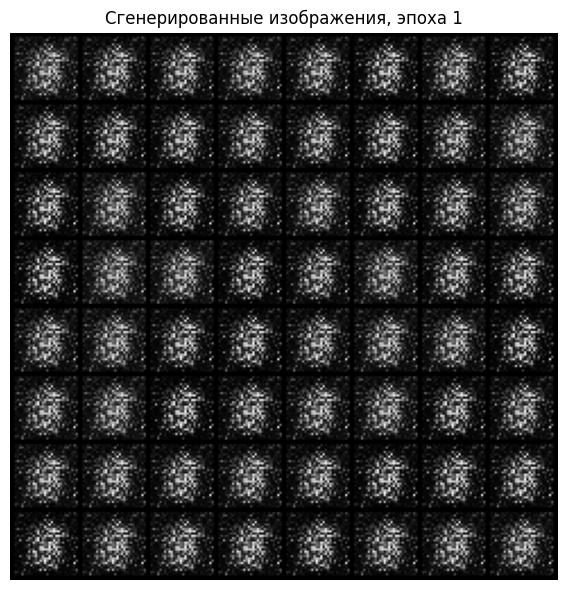

Эпоха 2/20 | loss_G=0.6795, loss_D=1.3486
Эпоха 3/20 | loss_G=0.7574, loss_D=1.2772
Эпоха 4/20 | loss_G=0.8294, loss_D=1.2355
Эпоха 5/20 | loss_G=0.9503, loss_D=1.2170


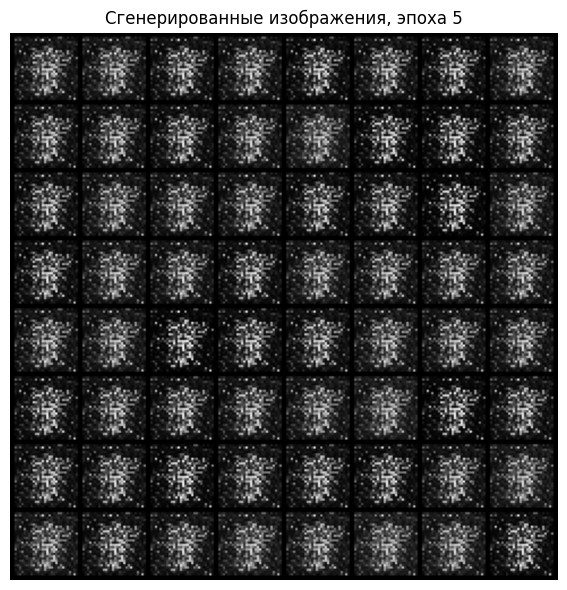

Эпоха 6/20 | loss_G=1.0274, loss_D=1.0673
Эпоха 7/20 | loss_G=1.1562, loss_D=1.1908
Эпоха 8/20 | loss_G=1.1751, loss_D=1.0822
Эпоха 9/20 | loss_G=1.3384, loss_D=1.1310
Эпоха 10/20 | loss_G=1.3927, loss_D=1.0242


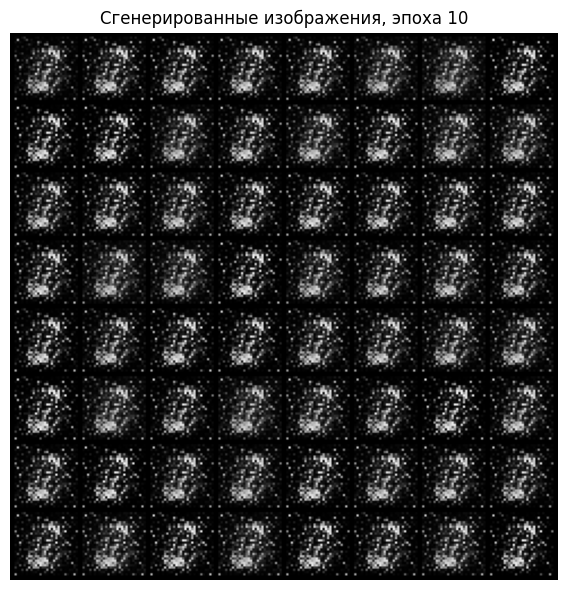

Эпоха 11/20 | loss_G=1.4965, loss_D=1.0760
Эпоха 12/20 | loss_G=1.4172, loss_D=0.9607
Эпоха 13/20 | loss_G=1.8017, loss_D=0.8971
Эпоха 14/20 | loss_G=1.7250, loss_D=0.9732
Эпоха 15/20 | loss_G=1.9785, loss_D=0.8062


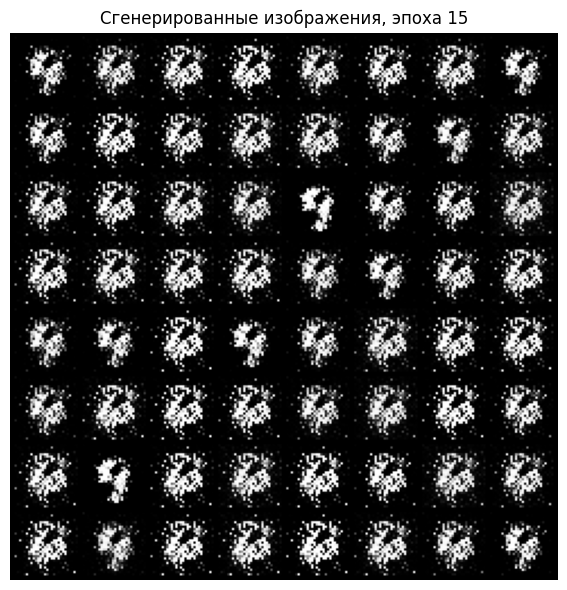

Эпоха 16/20 | loss_G=1.8832, loss_D=0.9036
Эпоха 17/20 | loss_G=2.1025, loss_D=0.6885
Эпоха 18/20 | loss_G=2.4027, loss_D=0.6002
Эпоха 19/20 | loss_G=2.8684, loss_D=0.6234
Эпоха 20/20 | loss_G=2.6297, loss_D=0.8292


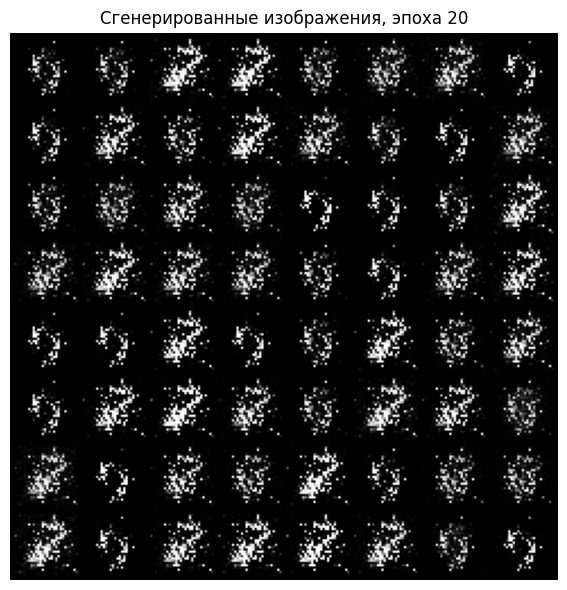

In [31]:
def train_gan(num_epochs):
    G.train()
    D.train()

    loss_history_G = []
    loss_history_D = []

    for epoch in range(1, num_epochs + 1):
        epoch_loss_G = 0.0
        epoch_loss_D = 0.0
        n_batches = 0

        for real_imgs, _ in train_loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            # --- шаг дискриминатора ---
            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # реал
            D_real = D(real_imgs)
            loss_D_real = criterion(D_real, real_labels)

            # фейк (detach, чтобы не обновлять G)
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z).detach()
            D_fake = D(fake_imgs)
            loss_D_fake = criterion(D_fake, fake_labels)

            loss_D = loss_D_real + loss_D_fake

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- шаг генератора ---
            z = torch.randn(bs, z_dim, device=device)
            fake_imgs = G(z)
            D_fake_for_G = D(fake_imgs)
            loss_G = criterion(D_fake_for_G, real_labels)  # хотим метку 1 для фейков

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            epoch_loss_G += loss_G.item()
            epoch_loss_D += loss_D.item()
            n_batches += 1

        avg_loss_G = epoch_loss_G / n_batches
        avg_loss_D = epoch_loss_D / n_batches
        loss_history_G.append(avg_loss_G)
        loss_history_D.append(avg_loss_D)

        print(f"Эпоха {epoch}/{num_epochs} | loss_G={avg_loss_G:.4f}, loss_D={avg_loss_D:.4f}")

        # визуальный мониторинг качества генератора
        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                samples = G(fixed_z).cpu()
            G.train()

            grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
            plt.figure(figsize=(6, 6))
            plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
            plt.axis("off")
            plt.title(f"Сгенерированные изображения, эпоха {epoch}")
            plt.tight_layout()
            plt.show()

    return loss_history_G, loss_history_D

num_epochs = 20  # в отчёте попробуйте другие значения и сравните
loss_G, loss_D = train_gan(num_epochs)

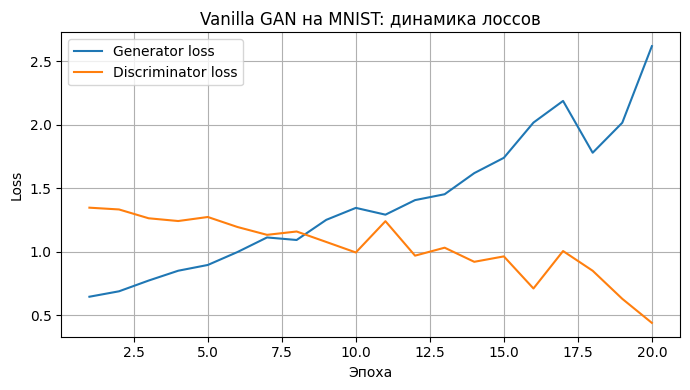

In [27]:
epochs_arr = np.arange(1, num_epochs + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_arr, loss_G, label="Generator loss")
plt.plot(epochs_arr, loss_D, label="Discriminator loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Vanilla GAN на MNIST: динамика лоссов")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

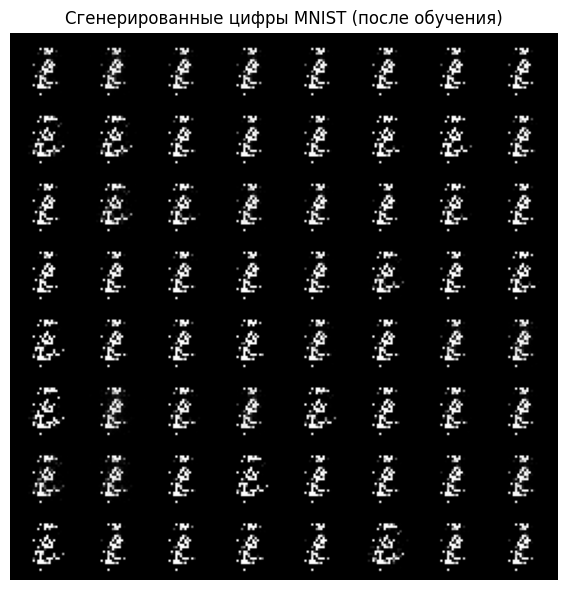

In [28]:
G.eval()
with torch.no_grad():
    z = torch.randn(64, z_dim, device=device)
    gen_imgs = G(z).cpu()

grid = utils.make_grid(gen_imgs, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Сгенерированные цифры MNIST (после обучения)")
plt.tight_layout()
plt.show()

In [ ]:
final_summary = """КОГДА ВЫ СДЕЛАЕТЕ СВОИ ВАРИАЦИИ GAN (АРХИТЕКТУРА, z_dim,
ГИПЕРПАРАМЕТРЫ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ, ЧТОБЫ СФОРМУЛИРОВАТЬ ИТОГОВЫЕ
ВЫВОДЫ: КАКИЕ НАСТРОЙКИ ДАЮТ ЛУЧШЕЕ СОЧЕТАНИЕ СТАБИЛЬНОСТИ ОБУЧЕНИЯ И
КАЧЕСТВА СГЕНЕРИРОВАННЫХ ЦИФР, И КАКИЕ ПРАКТИЧЕСКИЕ ПРАВИЛА ВЫ ДЛЯ СЕБЯ
ВЫВЕЛИ ДЛЯ НАСТРОЙКИ VANILLA GAN НА MNIST.

Уменьшив z_dim цифры уже стали проявляться, уже можно различить 1 и 9.
В целом, это были лучшие настройки для модели, на остальных никак не мог подобрать правильные значения - 
в большинстве случаев сгенерированные картинки походили на персонажей из 8-ми битных игр, или шум.

Пытался также разграничить скорость обучения для генератора и дискриминатора, создав lr_G и lr_D соответственно,
стало лучше, лоссы генератора уже не поднебесные, а колеблются в районе 1.5, но дискриминатор все равно выигрывает.
"""
print(final_summary)

КОГДА ВЫ СДЕЛАЕТЕ СВОИ ВАРИАЦИИ GAN (АРХИТЕКТУРА, z_dim,
ГИПЕРПАРАМЕТРЫ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ, ЧТОБЫ СФОРМУЛИРОВАТЬ ИТОГОВЫЕ
ВЫВОДЫ: КАКИЕ НАСТРОЙКИ ДАЮТ ЛУЧШЕЕ СОЧЕТАНИЕ СТАБИЛЬНОСТИ ОБУЧЕНИЯ И
КАЧЕСТВА СГЕНЕРИРОВАННЫХ ЦИФР, И КАКИЕ ПРАКТИЧЕСКИЕ ПРАВИЛА ВЫ ДЛЯ СЕБЯ
ВЫВЕЛИ ДЛЯ НАСТРОЙКИ VANILLA GAN НА MNIST.

Уменьшив z_dim цифры уже стали проявляться, уже можно различить 1 и 9.
В целом, это были лучшие настройки для модели, на остальных никак не мог подобрать правильные значения - 
в большинстве случаев сгенерированные картинки походили на персонажей из 8-ми битных игр, или шум.

Пытался также разграничить скорость обучения для генератора и дискриминатора, создав lr_G и lr_D соответственно,
стало лучше, лоссы 


